# Experiment: Cleaned Twitch Sarcasm Ablations

This notebook re-runs the Twitch binary task after removing obvious leakage cues from the text.

Study scope:
- retain the original `sarcasm` versus `regular` task
- evaluate two cleaned variants: `no_label_tags` and `no_hashtags`
- compare the cleaned results against the saved raw-data baseline


In [1]:
# Setup: verify runtime dependencies for this notebook
import importlib.util
import sys
from textwrap import dedent

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "torch": "torch",
    "IPython": "ipython",
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    raise ModuleNotFoundError(
        dedent(
            f"""
            Missing notebook dependencies: {', '.join(missing_packages)}

            Create and select a local virtualenv kernel before rerunning this notebook:
              {sys.executable} -m venv .venv
              source .venv/bin/activate
              python -m pip install --upgrade pip
              python -m pip install -r requirements-notebooks.txt
              python -m ipykernel install --user --name aml-project

            Then switch the notebook kernel to `aml-project`.
            """.strip()
        )
    )
else:
    print("All required packages are already installed in the active kernel.")


All required packages are already installed in the active kernel.


In [2]:
# Imports, reproducibility, and configuration
from __future__ import annotations

import copy
import html
import math
import random
import re
import unicodedata
import warnings
from collections import Counter
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


def find_project_root() -> Path:
    dataset_indicators = [
        Path("Dataset") / "Twitch" / "train.csv",
        Path("Dataset") / "Twitch" / "test.csv",
        Path("Dataset") / "Twitch.zip",
    ]
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if any((candidate / relative_path).exists() for relative_path in dataset_indicators):
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Expected Dataset/Twitch/train.csv and Dataset/Twitch/test.csv, "
        "or a Dataset/Twitch.zip archive."
    )


PROJECT_ROOT = find_project_root()
TRAIN_PATH = PROJECT_ROOT / "Dataset" / "Twitch" / "train.csv"
TEST_PATH = PROJECT_ROOT / "Dataset" / "Twitch" / "test.csv"
TWITCH_ARCHIVE_PATH = PROJECT_ROOT / "Dataset" / "Twitch.zip"
BASELINE_NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "Notebooks"
    / "jupyter-notebook"
    / "sarcasm-detection-comparison.ipynb"
)

LABEL_MAP = {"regular": 0, "sarcasm": 1}
LABEL_NAMES = {0: "regular", 1: "sarcasm"}
CLEANED_VARIANTS = ["no_label_tags", "no_hashtags"]

CONFIG = {
    "seed": SEED,
    "validation_size": 0.15,
    "max_vocab_size": 15000,
    "min_token_frequency": 2,
    "batch_size": 128,
    "embedding_dim": 128,
    "hidden_dim": 128,
    "lstm_layers": 1,
    "transformer_layers": 2,
    "transformer_heads": 4,
    "transformer_ff_dim": 256,
    "dropout": 0.25,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 8,
    "early_stopping_patience": 2,
    "gradient_clip": 1.0,
    "max_length_cap": 40,
    "max_length_floor": 12,
}

RAW_BASELINE_REFERENCE = {
    "notebook_path": str(BASELINE_NOTEBOOK_PATH),
    "headline": "The saved raw-Twitch baseline notebook reached near-perfect performance because the task leaked its own labels.",
    "example": "In the saved baseline run, TF-IDF test F1 was about 0.9998, which is not a believable real-world sarcasm result.",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
pd.set_option("display.max_colwidth", 140)


Using device: cpu


## Baseline Context

The raw Twitch benchmark is retained as a reference because the dataset contains explicit self-labeling cues. This notebook audits those cues and measures how performance changes after they are removed.


In [3]:
assert BASELINE_NOTEBOOK_PATH.exists(), "Expected baseline notebook is missing."

baseline_reference_df = pd.DataFrame(
    [
        {
            "baseline_notebook": RAW_BASELINE_REFERENCE["notebook_path"],
            "interpretation": RAW_BASELINE_REFERENCE["headline"],
            "example_result": RAW_BASELINE_REFERENCE["example"],
        }
    ]
)
display(baseline_reference_df)


,baseline_notebook,interpretation,example_result
0,/Users/abdoubarro/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/sarcasm-detection-comparison.ipynb,The saved raw-Twitch baseline notebook reached near-perfect performance because the task leaked its own labels.,"In the saved baseline run, TF-IDF test F1 was about 0.9998, which is not a believable real-world sarcasm result."


## Binary Twitch Loading

We keep only the binary subset needed for the report-facing comparison:

- `sarcasm -> 1`
- `regular -> 0`

Rows with `irony`, `figurative`, blank labels, or empty tweet text are dropped before any variant-specific cleaning.


In [4]:
# Shared text preprocessing, cleaning, and data helpers
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"[#＃](\w+)")
ALL_HASHTAGS_PATTERN = re.compile(r"[#＃]\w+")
LABEL_TAG_PATTERN = re.compile(r"(?i)[#＃]sarcasm\b|[#＃]sarcastic\b|(?<!\w)/s(?!\w)")
TOKEN_PATTERN = re.compile(r"<url>|<user>|hashtag_[a-z0-9_]+|<empty>|[a-z0-9']+|[!?.,;:()]+")
RAW_MARKER_PATTERNS = {
    "#sarcasm": re.compile(r"(?i)[#＃]sarcasm\b"),
    "#sarcastic": re.compile(r"(?i)[#＃]sarcastic\b"),
    "/s": re.compile(r"(?i)(?<!\w)/s(?!\w)"),
}


def normalize_text(text: str) -> str:
    """Normalize text while preserving placeholders and punctuation cues."""
    if not isinstance(text, str):
        return "<empty>"
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.lower().strip()
    text = URL_PATTERN.sub(" <url> ", text)
    text = MENTION_PATTERN.sub(" <user> ", text)
    text = HASHTAG_PATTERN.sub(lambda match: f" hashtag_{match.group(1)} ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text if text else "<empty>"


def tokenize_text(text: str) -> list[str]:
    """Tokenize normalized text into words, placeholders, and punctuation cues."""
    if not text:
        return ["<empty>"]
    tokens = TOKEN_PATTERN.findall(text)
    return tokens if tokens else ["<empty>"]


def remove_label_tags(text: str) -> str:
    """Remove explicit sarcasm self-labels while leaving other hashtags intact."""
    text = LABEL_TAG_PATTERN.sub(" ", str(text))
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def remove_all_hashtags(text: str) -> str:
    """Remove all hashtags before normalization."""
    text = ALL_HASHTAGS_PATTERN.sub(" ", str(text))
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def read_twitch_split(csv_path: Path, archive_path: Path, member_name: str) -> pd.DataFrame:
    """Read a Twitch split from an extracted CSV or directly from the zip archive."""
    if csv_path.exists():
        return pd.read_csv(csv_path)
    if archive_path.exists():
        with ZipFile(archive_path) as zip_file:
            with zip_file.open(member_name) as handle:
                return pd.read_csv(handle)
    raise FileNotFoundError(
        "Twitch data not found. Provide Dataset/Twitch/train.csv and Dataset/Twitch/test.csv, "
        "or place the original archive at Dataset/Twitch.zip."
    )


def load_twitch_binary_data(
    train_path: Path,
    test_path: Path,
    archive_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load Twitch data and keep only the binary sarcasm vs regular subset."""

    def prepare_split(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
        frame = frame.rename(columns={"tweets": "tweet", "class": "label_name"}).copy()
        frame = frame[frame["label_name"].isin(LABEL_MAP)].copy()
        frame["tweet"] = frame["tweet"].fillna("").astype(str).str.strip()
        frame = frame[frame["tweet"] != ""].copy()
        frame["label"] = frame["label_name"].map(LABEL_MAP).astype(int)
        frame["split"] = split_name
        return frame.reset_index(drop=True)

    train_df = prepare_split(read_twitch_split(train_path, archive_path, "train.csv"), "train")
    test_df = prepare_split(read_twitch_split(test_path, archive_path, "test.csv"), "test")
    return train_df, test_df


def prepare_variant_frame(frame: pd.DataFrame, variant_name: str) -> pd.DataFrame:
    """Create a cleaned variant frame from the same underlying raw rows."""
    cleaners = {
        "baseline_reference": lambda text: str(text).strip(),
        "no_label_tags": remove_label_tags,
        "no_hashtags": remove_all_hashtags,
    }
    if variant_name not in cleaners:
        raise ValueError(f"Unknown variant: {variant_name}")

    variant_frame = frame.copy()
    variant_frame["cleaned_text"] = variant_frame["tweet"].map(cleaners[variant_name])
    variant_frame["normalized_text"] = variant_frame["cleaned_text"].map(normalize_text)
    variant_frame["tokens"] = variant_frame["normalized_text"].map(tokenize_text)
    variant_frame["token_count"] = variant_frame["tokens"].map(len)
    variant_frame["variant"] = variant_name
    return variant_frame.reset_index(drop=True)


def summarize_marker_rates(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """Summarize label-marker prevalence in raw text."""
    rows = []
    for label_name in ["regular", "sarcasm"]:
        subset = frame[frame["label_name"] == label_name]
        total = len(subset)
        for marker_name, marker_pattern in RAW_MARKER_PATTERNS.items():
            share = subset["tweet"].str.contains(marker_pattern, regex=True).mean() if total else 0.0
            rows.append(
                {
                    "split": split_name,
                    "label_name": label_name,
                    "marker": marker_name,
                    "share": float(share),
                }
            )
    return pd.DataFrame(rows)


def assert_variant_clean(frame: pd.DataFrame, variant_name: str) -> None:
    """Verify that the requested cleaning actually happened."""
    if variant_name == "no_label_tags":
        assert not frame["cleaned_text"].str.contains(RAW_MARKER_PATTERNS["#sarcasm"], regex=True).any()
        assert not frame["cleaned_text"].str.contains(RAW_MARKER_PATTERNS["#sarcastic"], regex=True).any()
        assert not frame["cleaned_text"].str.contains(RAW_MARKER_PATTERNS["/s"], regex=True).any()
        assert "hashtag_sarcasm" not in set(token for tokens in frame["tokens"] for token in tokens)
        assert "hashtag_sarcastic" not in set(token for tokens in frame["tokens"] for token in tokens)
    elif variant_name == "no_hashtags":
        assert not frame["cleaned_text"].str.contains(ALL_HASHTAGS_PATTERN, regex=True).any()
        assert not any(token.startswith("hashtag_") for tokens in frame["tokens"] for token in tokens)


def build_vocab(
    texts: pd.Series,
    min_frequency: int = 2,
    max_vocab_size: int | None = None,
) -> tuple[dict[str, int], Counter]:
    """Build a vocabulary from training text only."""
    counter = Counter()
    for text in texts:
        counter.update(tokenize_text(text))

    vocab = {"<pad>": 0, "<unk>": 1}
    for token, count in counter.most_common():
        if count < min_frequency:
            continue
        if max_vocab_size is not None and len(vocab) >= max_vocab_size:
            break
        vocab[token] = len(vocab)
    return vocab, counter


def encode_and_pad(
    texts: pd.Series,
    vocab: dict[str, int],
    max_length: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert text to fixed-length token id arrays."""
    sequences: list[list[int]] = []
    lengths: list[int] = []
    unk_idx = vocab["<unk>"]
    pad_idx = vocab["<pad>"]

    for text in texts:
        token_ids = [vocab.get(token, unk_idx) for token in tokenize_text(text)]
        token_ids = token_ids[:max_length]
        effective_length = max(1, len(token_ids))
        if not token_ids:
            token_ids = [unk_idx]
        padded = token_ids + [pad_idx] * (max_length - len(token_ids))
        sequences.append(padded[:max_length])
        lengths.append(min(effective_length, max_length))

    return np.asarray(sequences, dtype=np.int64), np.asarray(lengths, dtype=np.int64)


In [5]:
raw_train_df, raw_test_df = load_twitch_binary_data(TRAIN_PATH, TEST_PATH, TWITCH_ARCHIVE_PATH)

expected_counts = {"train": 39276, "test": 3964}
observed_counts = {"train": len(raw_train_df), "test": len(raw_test_df)}
for split_name, expected_count in expected_counts.items():
    observed_count = observed_counts[split_name]
    print(f"{split_name}: observed={observed_count:,}, expected={expected_count:,}")
    assert observed_count == expected_count, f"Unexpected count for {split_name}: {observed_count}"

display(raw_train_df[["tweet", "label_name"]].head(5))


train: observed=39,276, expected=39,276
test: observed=3,964, expected=3,964


,tweet,label_name
0,New #quote : It's both a blessing and a curse to feel so much. #mondayinspiration #late #quote #emotion #feel #emp… http://t.co/5zLIMGgH70,regular
1,"Daddy Uncle Bubba (#life, love, loss, #laughter &amp; Parkinson's): #DreamTherapy http://t.co/VsJWnJin5i #parkie #late #coach #basketball #",regular
2,Ayvee - Where Im From on #SoundCloud #late #night #musicafterdark #banger #rap #hip #hop #drake #lil #wayne #hot #np https://t.co/59fSxl...,regular
3,#late starting #dinner #tonight but here is what I'm #prepping to go in #mushrooms #redpepper… https://t.co/fBikZ7fOBY,regular
4,@Trillakayy__ happy birthdayyyyy #late 😅,regular


## Variant-Aware Cleaning

We train on two cleaned variants:

- `no_label_tags`: remove `#sarcasm`, `#sarcastic`, and standalone `/s`, then normalize the rest
- `no_hashtags`: remove *all* hashtags before normalization

The first variant asks whether explicit self-labels were doing most of the work. The second asks whether hashtag-heavy metadata still makes the task artificially easy even after removing the obvious sarcasm tags.


In [6]:
example_rows = pd.concat(
    [
        raw_train_df[raw_train_df["label_name"] == "sarcasm"].head(3),
        raw_train_df[raw_train_df["label_name"] == "regular"].head(3),
    ],
    ignore_index=True,
)

example_transform_df = example_rows[["label_name", "tweet"]].copy()
example_transform_df["no_label_tags"] = example_transform_df["tweet"].map(remove_label_tags)
example_transform_df["no_hashtags"] = example_transform_df["tweet"].map(remove_all_hashtags)
display(example_transform_df)


,label_name,tweet,no_label_tags,no_hashtags
0,sarcasm,"“@ThinkingHumanit: #Sarcastic People Are Actually #Smarter, #Sexier And More #Successful http://t.co/wPtGBx3nrG”","“@ThinkingHumanit: People Are Actually #Smarter, #Sexier And More #Successful http://t.co/wPtGBx3nrG”","“@ThinkingHumanit: People Are Actually , And More http://t.co/wPtGBx3nrG”"
1,sarcasm,Be aware dirty step to get money #staylight #staywhite #sarcastic #moralneeded @… https://t.co/Oj6BdyX3WG,Be aware dirty step to get money #staylight #staywhite #moralneeded @… https://t.co/Oj6BdyX3WG,Be aware dirty step to get money @… https://t.co/Oj6BdyX3WG
2,sarcasm,In CA for 5 days and it rains 2 of them. #imaginarydrought #dontbelievethehype #sarcasm,In CA for 5 days and it rains 2 of them. #imaginarydrought #dontbelievethehype,In CA for 5 days and it rains 2 of them.
3,regular,New #quote : It's both a blessing and a curse to feel so much. #mondayinspiration #late #quote #emotion #feel #emp… http://t.co/5zLIMGgH70,New #quote : It's both a blessing and a curse to feel so much. #mondayinspiration #late #quote #emotion #feel #emp… http://t.co/5zLIMGgH70,New : It's both a blessing and a curse to feel so much. … http://t.co/5zLIMGgH70
4,regular,"Daddy Uncle Bubba (#life, love, loss, #laughter &amp; Parkinson's): #DreamTherapy http://t.co/VsJWnJin5i #parkie #late #coach #basketball #","Daddy Uncle Bubba (#life, love, loss, #laughter &amp; Parkinson's): #DreamTherapy http://t.co/VsJWnJin5i #parkie #late #coach #basketball #","Daddy Uncle Bubba ( , love, loss, &amp; Parkinson's): http://t.co/VsJWnJin5i #"
5,regular,Ayvee - Where Im From on #SoundCloud #late #night #musicafterdark #banger #rap #hip #hop #drake #lil #wayne #hot #np https://t.co/59fSxl...,Ayvee - Where Im From on #SoundCloud #late #night #musicafterdark #banger #rap #hip #hop #drake #lil #wayne #hot #np https://t.co/59fSxl...,Ayvee - Where Im From on https://t.co/59fSxlqR3h


## Leakage Audit And Sanity Checks

This is the key diagnosis section. It measures how frequently raw Twitch examples directly reveal the label, then verifies that the cleaned variants:

- keep the same underlying rows
- remove the intended leakage cues
- produce tokenized text suitable for the same model family


In [7]:
variant_frames = {
    variant_name: {
        "train": prepare_variant_frame(raw_train_df, variant_name),
        "test": prepare_variant_frame(raw_test_df, variant_name),
    }
    for variant_name in CLEANED_VARIANTS
}

for variant_name in CLEANED_VARIANTS:
    for split_name in ["train", "test"]:
        frame = variant_frames[variant_name][split_name]
        expected_rows = len(raw_train_df) if split_name == "train" else len(raw_test_df)
        assert len(frame) == expected_rows, f"Row count changed for {variant_name} {split_name}"
    assert_variant_clean(variant_frames[variant_name]["train"], variant_name)
    assert_variant_clean(variant_frames[variant_name]["test"], variant_name)

raw_marker_audit_df = pd.concat(
    [
        summarize_marker_rates(raw_train_df, "train"),
        summarize_marker_rates(raw_test_df, "test"),
    ],
    ignore_index=True,
)

variant_sanity_rows = []
for variant_name, split_frames in variant_frames.items():
    for split_name, frame in split_frames.items():
        variant_sanity_rows.append(
            {
                "variant": variant_name,
                "split": split_name,
                "rows": len(frame),
                "avg_token_count": frame["token_count"].mean(),
                "p95_token_count": frame["token_count"].quantile(0.95),
                "contains_hashtag_tokens": any(
                    token.startswith("hashtag_")
                    for tokens in frame["tokens"]
                    for token in tokens
                ),
            }
        )

variant_sanity_df = pd.DataFrame(variant_sanity_rows)
display(raw_marker_audit_df.pivot_table(index=["split", "label_name"], columns="marker", values="share"))
display(variant_sanity_df)


marker            #sarcasm  #sarcastic   /s
split label_name                           
test  regular     0.000000    0.000000  0.0
      sarcasm     0.951544    0.051781  0.0
train regular     0.000000    0.000000  0.0
      sarcasm     0.947488    0.055607  0.0

,variant,split,rows,avg_token_count,p95_token_count,contains_hashtag_tokens
0,no_label_tags,train,39276,15.320297,25.0,True
1,no_label_tags,test,3964,15.423310,25.0,True
2,no_hashtags,train,39276,13.284194,24.0,False
3,no_hashtags,test,3964,13.400101,24.0,False


## Shared Split Strategy

To keep the ablation fair, both cleaned variants use the **same underlying train / validation split** derived from the raw filtered training rows. Only the text transformation changes across variants.


In [8]:
raw_indices = np.arange(len(raw_train_df))
train_indices, val_indices = train_test_split(
    raw_indices,
    test_size=CONFIG["validation_size"],
    stratify=raw_train_df["label"],
    random_state=SEED,
)
train_indices = np.sort(train_indices)
val_indices = np.sort(val_indices)

SPLIT_INDICES = {"train": train_indices, "validation": val_indices}


def get_variant_split_frames(variant_name: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_frame = variant_frames[variant_name]["train"].iloc[SPLIT_INDICES["train"]].reset_index(drop=True)
    val_frame = variant_frames[variant_name]["train"].iloc[SPLIT_INDICES["validation"]].reset_index(drop=True)
    test_frame = variant_frames[variant_name]["test"].reset_index(drop=True)
    return train_frame, val_frame, test_frame


split_summary_rows = []
for variant_name in CLEANED_VARIANTS:
    train_frame, val_frame, test_frame = get_variant_split_frames(variant_name)
    for split_name, frame in [("train", train_frame), ("validation", val_frame), ("test", test_frame)]:
        split_summary_rows.append(
            {
                "variant": variant_name,
                "split": split_name,
                "rows": len(frame),
                "sarcasm_share": frame["label"].mean(),
                "avg_token_count": frame["token_count"].mean(),
                "p95_token_count": frame["token_count"].quantile(0.95),
            }
        )

split_summary_df = pd.DataFrame(split_summary_rows)
display(split_summary_df)


,variant,split,rows,sarcasm_share,avg_token_count,p95_token_count
0,no_label_tags,train,33384,0.526570,15.320543,25.0
1,no_label_tags,validation,5892,0.526477,15.318907,25.0
2,no_label_tags,test,3964,0.531029,15.423310,25.0
3,no_hashtags,train,33384,0.526570,13.277378,24.0
4,no_hashtags,validation,5892,0.526477,13.322811,24.0
5,no_hashtags,test,3964,0.531029,13.400101,24.0


## TF-IDF Experiments

The lexical baseline is kept unchanged at the model level. Only the input text variant changes, which lets us see how much its earlier near-perfect performance depended on leaking hashtags.


In [9]:
def compute_classification_metrics(y_true, y_pred) -> dict[str, float]:
    """Compute standard binary classification metrics."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def show_confusion_matrix(y_true, y_pred, title: str, ax=None):
    """Visualize a confusion matrix using seaborn."""
    matrix = confusion_matrix(y_true, y_pred)
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
        yticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    return ax


def collect_error_cases(
    frame: pd.DataFrame,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    model_name: str,
    variant_name: str,
    top_n: int = 5,
) -> pd.DataFrame:
    """Collect the most confident false positives and false negatives."""
    analysis_df = frame[["tweet", "cleaned_text", "normalized_text", "label", "label_name"]].copy()
    analysis_df["predicted_label"] = predictions.astype(int)
    analysis_df["predicted_label_name"] = analysis_df["predicted_label"].map(LABEL_NAMES)
    analysis_df["predicted_probability"] = probabilities
    analysis_df["confidence"] = np.where(
        analysis_df["predicted_label"] == 1,
        analysis_df["predicted_probability"],
        1.0 - analysis_df["predicted_probability"],
    )
    errors = analysis_df[analysis_df["predicted_label"] != analysis_df["label"]].copy()
    errors["model"] = model_name
    errors["variant"] = variant_name
    errors["error_type"] = np.where(
        (errors["label"] == 0) & (errors["predicted_label"] == 1),
        "false_positive",
        "false_negative",
    )

    top_false_positives = (
        errors[errors["error_type"] == "false_positive"]
        .sort_values("confidence", ascending=False)
        .head(top_n)
    )
    top_false_negatives = (
        errors[errors["error_type"] == "false_negative"]
        .sort_values("confidence", ascending=False)
        .head(top_n)
    )
    return pd.concat([top_false_positives, top_false_negatives], ignore_index=True)


def run_tfidf_experiment(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    variant_name: str,
) -> dict:
    """Fit and evaluate the TF-IDF baseline on one cleaned variant."""
    baseline_model = Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=20000,
                    sublinear_tf=True,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=SEED,
                ),
            ),
        ]
    )

    baseline_model.fit(train_frame["normalized_text"], train_frame["label"])

    results = []
    predictions = {}
    probabilities = {}
    for split_name, frame in {"validation": val_frame, "test": test_frame}.items():
        split_probabilities = baseline_model.predict_proba(frame["normalized_text"])[:, 1]
        split_predictions = (split_probabilities >= 0.5).astype(int)
        metrics = compute_classification_metrics(frame["label"], split_predictions)
        metrics.update(
            {
                "variant": variant_name,
                "model": "TF-IDF + Logistic Regression",
                "split": split_name,
            }
        )
        results.append(metrics)
        predictions[split_name] = split_predictions
        probabilities[split_name] = split_probabilities

    return {
        "results": results,
        "predictions": predictions,
        "probabilities": probabilities,
    }


## Bidirectional LSTM Experiments

The BiLSTM keeps the same sequence-classification role as before, but now each cleaned variant gets its own vocabulary and padded sequence representation so removed leakage tokens cannot re-enter through the preprocessing pipeline.


In [10]:
def build_vocab(
    texts: pd.Series,
    min_frequency: int = 2,
    max_vocab_size: int | None = None,
) -> tuple[dict[str, int], Counter]:
    """Build a vocabulary from training text only."""
    counter = Counter()
    for text in texts:
        counter.update(tokenize_text(text))

    vocab = {"<pad>": 0, "<unk>": 1}
    for token, count in counter.most_common():
        if count < min_frequency:
            continue
        if max_vocab_size is not None and len(vocab) >= max_vocab_size:
            break
        vocab[token] = len(vocab)
    return vocab, counter


def encode_and_pad(
    texts: pd.Series,
    vocab: dict[str, int],
    max_length: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert text to fixed-length token-id arrays."""
    sequences = []
    lengths = []
    unk_idx = vocab["<unk>"]
    pad_idx = vocab["<pad>"]

    for text in texts:
        token_ids = [vocab.get(token, unk_idx) for token in tokenize_text(text)]
        token_ids = token_ids[:max_length]
        effective_length = max(1, len(token_ids))
        if not token_ids:
            token_ids = [unk_idx]
        padded = token_ids + [pad_idx] * (max_length - len(token_ids))
        sequences.append(padded[:max_length])
        lengths.append(min(effective_length, max_length))

    return np.asarray(sequences, dtype=np.int64), np.asarray(lengths, dtype=np.int64)


class TextClassificationDataset(Dataset):
    """Fixed-length text classification dataset."""

    def __init__(self, input_ids: np.ndarray, lengths: np.ndarray, labels: np.ndarray):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        return self.input_ids[idx], self.lengths[idx], self.labels[idx]


def prepare_sequence_bundle(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    variant_name: str,
) -> dict:
    """Build a variant-specific vocabulary and dataloaders."""
    max_length = int(train_frame["token_count"].quantile(0.95))
    max_length = max(CONFIG["max_length_floor"], min(CONFIG["max_length_cap"], max_length))

    vocab, token_counter = build_vocab(
        train_frame["normalized_text"],
        min_frequency=CONFIG["min_token_frequency"],
        max_vocab_size=CONFIG["max_vocab_size"],
    )

    if variant_name == "no_label_tags":
        assert "hashtag_sarcasm" not in vocab
        assert "hashtag_sarcastic" not in vocab
    elif variant_name == "no_hashtags":
        assert not any(token.startswith("hashtag_") for token in vocab)

    def make_dataset(frame: pd.DataFrame) -> TextClassificationDataset:
        input_ids, lengths = encode_and_pad(frame["normalized_text"], vocab, max_length)
        labels = frame["label"].to_numpy(dtype=np.float32)
        return TextClassificationDataset(input_ids, lengths, labels)

    train_dataset = make_dataset(train_frame)
    val_dataset = make_dataset(val_frame)
    test_dataset = make_dataset(test_frame)

    return {
        "vocab": vocab,
        "token_counter": token_counter,
        "max_length": max_length,
        "pad_idx": vocab["<pad>"],
        "train_loader": DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True),
        "val_loader": DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False),
        "test_loader": DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False),
    }


def run_epoch(model, dataloader, criterion, optimizer=None):
    """Run one epoch and return loss, predictions, and metrics."""
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    all_probabilities = []
    all_predictions = []
    all_labels = []

    for input_ids, lengths, labels in dataloader:
        input_ids = input_ids.to(DEVICE)
        lengths = lengths.to(DEVICE)
        labels = labels.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["gradient_clip"])
                optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).long()

        total_loss += loss.item() * labels.size(0)
        all_probabilities.append(probabilities.detach().cpu().numpy())
        all_predictions.append(predictions.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    y_prob = np.concatenate(all_probabilities)
    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_labels).astype(int)
    metrics = compute_classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / len(dataloader.dataset)
    return metrics, y_prob, y_pred, y_true


def train_neural_model(model, train_loader, val_loader, model_name: str, variant_name: str):
    """Train a model with AdamW and early stopping on validation F1."""
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )

    best_state = None
    best_val_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, CONFIG["epochs"] + 1):
        train_metrics, *_ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics, *_ = run_epoch(model, val_loader, criterion, optimizer=None)

        history.append(
            {
                "variant": variant_name,
                "model": model_name,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_f1": train_metrics["f1"],
                "val_loss": val_metrics["loss"],
                "val_f1": val_metrics["f1"],
                "val_accuracy": val_metrics["accuracy"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
            }
        )

        print(
            f"{variant_name} | {model_name} | epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | train_f1={train_metrics['f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
            print(f"Early stopping triggered for {variant_name} | {model_name}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def evaluate_neural_model(model, dataloader, split_name: str, model_name: str, variant_name: str):
    """Evaluate a trained neural model on a split."""
    criterion = nn.BCEWithLogitsLoss()
    metrics, probabilities, predictions, labels = run_epoch(
        model,
        dataloader,
        criterion,
        optimizer=None,
    )
    metrics.update({"variant": variant_name, "model": model_name, "split": split_name})
    return metrics, probabilities, predictions, labels


class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM text classifier."""

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.encoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden_state, _) = self.encoder(packed)
        forward_hidden = hidden_state[-2]
        backward_hidden = hidden_state[-1]
        features = torch.cat([forward_hidden, backward_hidden], dim=1)
        logits = self.classifier(self.dropout(features)).squeeze(-1)
        return logits


## Transformer Experiments

The Transformer stays encoder-only and uses the same binary classification head as before. Just like the BiLSTM, it receives a variant-specific vocabulary so removed leakage tokens cannot sneak back into the model.


In [11]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""

    def __init__(self, embedding_dim: int, max_length: int):
        super().__init__()
        positions = torch.arange(max_length).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embedding_dim, 2) * (-math.log(10000.0) / embedding_dim)
        )
        pe = torch.zeros(max_length, embedding_dim)
        pe[:, 0::2] = torch.sin(positions * div_term)
        pe[:, 1::2] = torch.cos(positions * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return inputs + self.pe[:, : inputs.size(1)]


class TransformerEncoderClassifier(nn.Module):
    """Encoder-only Transformer text classifier."""

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        num_heads: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
        pad_idx: int,
        max_length: int,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding_dim = embedding_dim
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.position = PositionalEncoding(embedding_dim, max_length)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embedding_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        padding_mask = input_ids.eq(self.pad_idx)
        embeddings = self.embedding(input_ids) * math.sqrt(self.embedding_dim)
        encoded = self.position(embeddings)
        encoded = self.encoder(encoded, src_key_padding_mask=padding_mask)

        valid_mask = (~padding_mask).unsqueeze(-1)
        pooled = (encoded * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1)
        logits = self.classifier(self.dropout(pooled)).squeeze(-1)
        return logits


def run_neural_experiment(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    variant_name: str,
    model_name: str,
    model_factory,
) -> dict:
    """Train and evaluate one neural model on one cleaned variant."""
    sequence_bundle = prepare_sequence_bundle(train_frame, val_frame, test_frame, variant_name)
    model = model_factory(sequence_bundle).to(DEVICE)
    model, history_df = train_neural_model(
        model,
        sequence_bundle["train_loader"],
        sequence_bundle["val_loader"],
        model_name=model_name,
        variant_name=variant_name,
    )

    results = []
    predictions = {}
    probabilities = {}
    for split_name, loader in {
        "validation": sequence_bundle["val_loader"],
        "test": sequence_bundle["test_loader"],
    }.items():
        metrics, split_probabilities, split_predictions, _ = evaluate_neural_model(
            model,
            loader,
            split_name=split_name,
            model_name=model_name,
            variant_name=variant_name,
        )
        results.append(metrics)
        predictions[split_name] = split_predictions
        probabilities[split_name] = split_probabilities

    return {
        "results": results,
        "predictions": predictions,
        "probabilities": probabilities,
        "history_df": history_df,
        "sequence_bundle": {
            "vocab_size": len(sequence_bundle["vocab"]),
            "max_length": sequence_bundle["max_length"],
            "top_tokens": sequence_bundle["token_counter"].most_common(12),
        },
    }


## Cross-Variant Experiment Orchestration

This is the main execution section. Each cleaned variant is run through:

- TF-IDF + Logistic Regression
- Bidirectional LSTM
- Encoder-only Transformer

All results are recorded in one long-form table so the comparison stays compact and easy to reuse.


In [12]:
def run_variant_suite(variant_name: str) -> tuple[list[dict], dict]:
    """Run all three models on one cleaned variant."""
    train_frame, val_frame, test_frame = get_variant_split_frames(variant_name)

    tfidf_artifact = run_tfidf_experiment(train_frame, val_frame, test_frame, variant_name)

    bilstm_artifact = run_neural_experiment(
        train_frame,
        val_frame,
        test_frame,
        variant_name=variant_name,
        model_name="Bidirectional LSTM",
        model_factory=lambda bundle: BiLSTMClassifier(
            vocab_size=len(bundle["vocab"]),
            embedding_dim=CONFIG["embedding_dim"],
            hidden_dim=CONFIG["hidden_dim"],
            num_layers=CONFIG["lstm_layers"],
            dropout=CONFIG["dropout"],
            pad_idx=bundle["pad_idx"],
        ),
    )

    transformer_artifact = run_neural_experiment(
        train_frame,
        val_frame,
        test_frame,
        variant_name=variant_name,
        model_name="Encoder-only Transformer",
        model_factory=lambda bundle: TransformerEncoderClassifier(
            vocab_size=len(bundle["vocab"]),
            embedding_dim=CONFIG["embedding_dim"],
            num_heads=CONFIG["transformer_heads"],
            num_layers=CONFIG["transformer_layers"],
            ff_dim=CONFIG["transformer_ff_dim"],
            dropout=CONFIG["dropout"],
            pad_idx=bundle["pad_idx"],
            max_length=bundle["max_length"],
        ),
    )

    all_results = (
        tfidf_artifact["results"]
        + bilstm_artifact["results"]
        + transformer_artifact["results"]
    )

    artifact = {
        "frames": {
            "train": train_frame,
            "validation": val_frame,
            "test": test_frame,
        },
        "models": {
            "TF-IDF + Logistic Regression": tfidf_artifact,
            "Bidirectional LSTM": bilstm_artifact,
            "Encoder-only Transformer": transformer_artifact,
        },
    }
    return all_results, artifact


all_results_records = []
variant_artifacts = {}

for variant_name in CLEANED_VARIANTS:
    print(f"\nRunning cleaned variant: {variant_name}")
    variant_results, variant_artifact = run_variant_suite(variant_name)
    all_results_records.extend(variant_results)
    variant_artifacts[variant_name] = variant_artifact

results_df = pd.DataFrame(all_results_records)
display(results_df)



Running cleaned variant: no_label_tags
no_label_tags | Bidirectional LSTM | epoch 01 | train_loss=0.1635 | train_f1=0.9457 | val_loss=0.0650 | val_f1=0.9858
no_label_tags | Bidirectional LSTM | epoch 02 | train_loss=0.0614 | train_f1=0.9853 | val_loss=0.0606 | val_f1=0.9859
no_label_tags | Bidirectional LSTM | epoch 03 | train_loss=0.0517 | train_f1=0.9861 | val_loss=0.0603 | val_f1=0.9849
no_label_tags | Bidirectional LSTM | epoch 04 | train_loss=0.0389 | train_f1=0.9881 | val_loss=0.0575 | val_f1=0.9862
no_label_tags | Bidirectional LSTM | epoch 05 | train_loss=0.0258 | train_f1=0.9916 | val_loss=0.0657 | val_f1=0.9859
no_label_tags | Bidirectional LSTM | epoch 06 | train_loss=0.0143 | train_f1=0.9956 | val_loss=0.0723 | val_f1=0.9818
Early stopping triggered for no_label_tags | Bidirectional LSTM.
no_label_tags | Encoder-only Transformer | epoch 01 | train_loss=0.1967 | train_f1=0.9325 | val_loss=0.0686 | val_f1=0.9860
no_label_tags | Encoder-only Transformer | epoch 02 | train_los

,accuracy,precision,recall,f1,variant,model,split,loss
0,0.989647,0.990010,0.990329,0.990169,no_label_tags,TF-IDF + Logistic Regression,validation,NaN
1,0.987134,0.988118,0.987648,0.987883,no_label_tags,TF-IDF + Logistic Regression,test,NaN
2,0.985404,0.984265,0.988072,0.986165,no_label_tags,Bidirectional LSTM,validation,0.057455
3,0.980827,0.977862,0.986223,0.982025,no_label_tags,Bidirectional LSTM,test,0.068244
4,0.985913,0.985214,0.988072,0.986641,no_label_tags,Encoder-only Transformer,validation,0.067343
5,0.983602,0.981586,0.987648,0.984608,no_label_tags,Encoder-only Transformer,test,0.069787
6,0.844026,0.838450,0.871696,0.854749,no_hashtags,TF-IDF + Logistic Regression,validation,NaN
7,0.838042,0.829060,0.875534,0.851664,no_hashtags,TF-IDF + Logistic Regression,test,NaN
8,0.840292,0.835872,0.866860,0.851084,no_hashtags,Bidirectional LSTM,validation,0.389769
9,0.836781,0.832270,0.867458,0.849500,no_hashtags,Bidirectional LSTM,test,0.392619


## Cross-Variant Comparison

The tables below are the main report-facing outputs for this notebook:

- all model metrics across both cleaned variants
- best test model per variant
- neural learning curves across variants


,variant,model,split,accuracy,precision,recall,f1
0,no_hashtags,TF-IDF + Logistic Regression,test,0.8380,0.8291,0.8755,0.8517
1,no_hashtags,Encoder-only Transformer,test,0.8295,0.7973,0.9102,0.8500
2,no_hashtags,Bidirectional LSTM,test,0.8368,0.8323,0.8675,0.8495
3,no_hashtags,TF-IDF + Logistic Regression,validation,0.8440,0.8384,0.8717,0.8547
4,no_hashtags,Bidirectional LSTM,validation,0.8403,0.8359,0.8669,0.8511
5,no_hashtags,Encoder-only Transformer,validation,0.8267,0.7993,0.8959,0.8448
6,no_label_tags,TF-IDF + Logistic Regression,test,0.9871,0.9881,0.9876,0.9879
7,no_label_tags,Encoder-only Transformer,test,0.9836,0.9816,0.9876,0.9846
8,no_label_tags,Bidirectional LSTM,test,0.9808,0.9779,0.9862,0.9820
9,no_label_tags,TF-IDF + Logistic Regression,validation,0.9896,0.9900,0.9903,0.9902


,variant,model,split,accuracy,precision,recall,f1
0,no_hashtags,TF-IDF + Logistic Regression,test,0.8380,0.8291,0.8755,0.8517
1,no_label_tags,TF-IDF + Logistic Regression,test,0.9871,0.9881,0.9876,0.9879


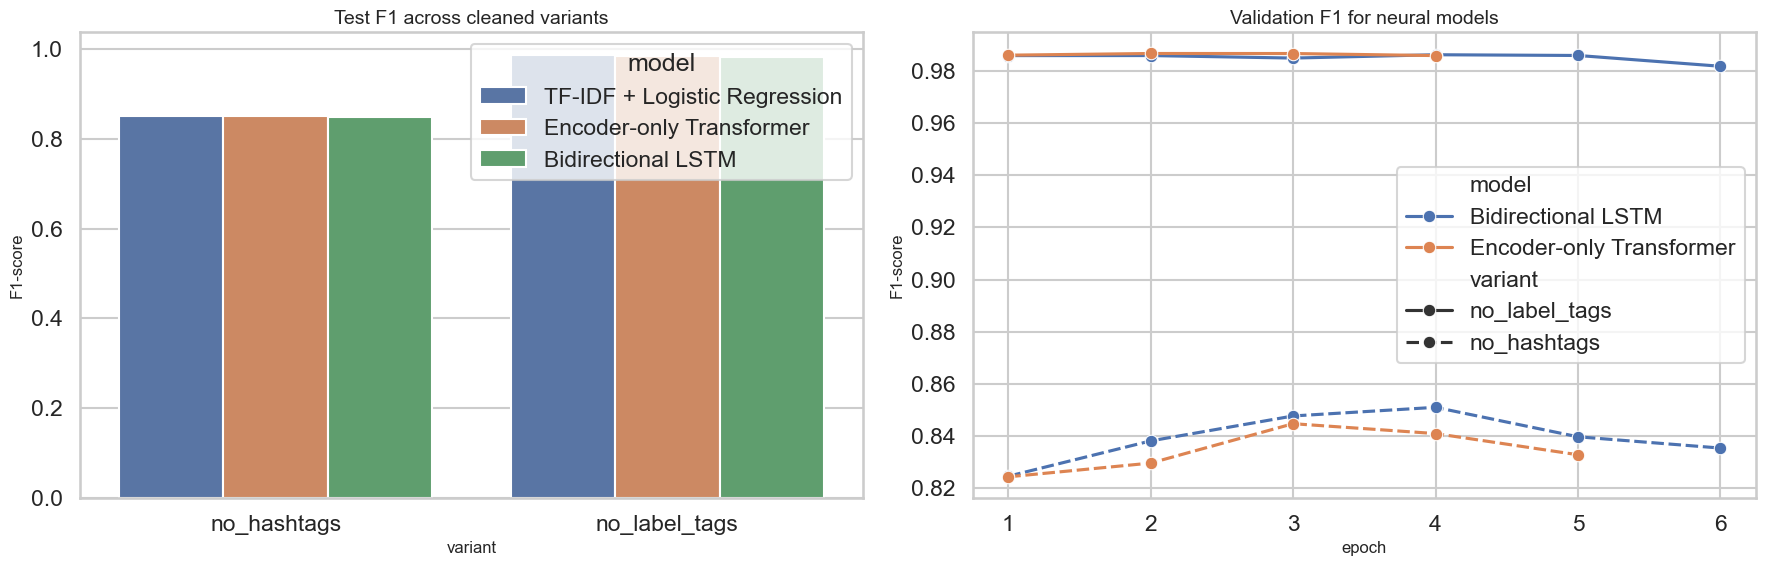

In [13]:
comparison_df = results_df[
    ["variant", "model", "split", "accuracy", "precision", "recall", "f1"]
].sort_values(["variant", "split", "f1"], ascending=[True, True, False]).reset_index(drop=True)

best_test_per_variant_df = (
    comparison_df[comparison_df["split"] == "test"]
    .sort_values(["variant", "f1"], ascending=[True, False])
    .groupby("variant", as_index=False)
    .first()
)

neural_history_df = pd.concat(
    [
        variant_artifacts[variant_name]["models"]["Bidirectional LSTM"]["history_df"]
        for variant_name in CLEANED_VARIANTS
    ]
    + [
        variant_artifacts[variant_name]["models"]["Encoder-only Transformer"]["history_df"]
        for variant_name in CLEANED_VARIANTS
    ],
    ignore_index=True,
)

display(
    comparison_df.style.format(
        {col: "{:.4f}" for col in ["accuracy", "precision", "recall", "f1"]}
    )
)
display(
    best_test_per_variant_df.style.format(
        {col: "{:.4f}" for col in ["accuracy", "precision", "recall", "f1"]}
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(
    data=comparison_df[comparison_df["split"] == "test"],
    x="variant",
    y="f1",
    hue="model",
    ax=axes[0],
)
axes[0].set_title("Test F1 across cleaned variants")
axes[0].set_ylabel("F1-score")
axes[0].set_xlabel("variant")
axes[0].tick_params(axis="x", rotation=0)

sns.lineplot(
    data=neural_history_df,
    x="epoch",
    y="val_f1",
    hue="model",
    style="variant",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Validation F1 for neural models")
axes[1].set_ylabel("F1-score")

plt.tight_layout()
plt.show()


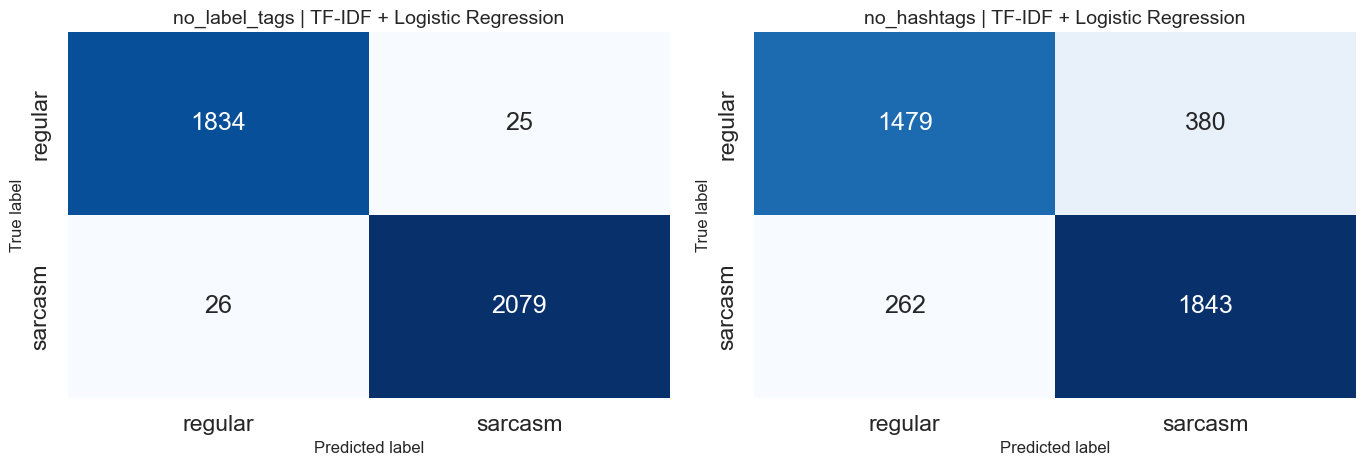

In [14]:
best_models_by_variant = {}
fig, axes = plt.subplots(1, len(CLEANED_VARIANTS), figsize=(7 * len(CLEANED_VARIANTS), 5))
if len(CLEANED_VARIANTS) == 1:
    axes = [axes]

for ax, variant_name in zip(axes, CLEANED_VARIANTS):
    best_row = (
        comparison_df[
            (comparison_df["variant"] == variant_name)
            & (comparison_df["split"] == "test")
        ]
        .sort_values("f1", ascending=False)
        .iloc[0]
    )
    model_name = best_row["model"]
    best_models_by_variant[variant_name] = model_name
    test_frame = variant_artifacts[variant_name]["frames"]["test"]
    predictions = variant_artifacts[variant_name]["models"][model_name]["predictions"]["test"]
    show_confusion_matrix(
        test_frame["label"],
        predictions,
        title=f"{variant_name} | {model_name}",
        ax=ax,
    )

plt.tight_layout()
plt.show()


## Error Analysis

The error analysis focuses on the strongest cleaned result across both variants. This isolates failure modes from the most credible low-leakage Twitch setting rather than from the near-perfect raw baseline.


In [15]:
overall_best_row = (
    comparison_df[comparison_df["split"] == "test"]
    .sort_values("f1", ascending=False)
    .iloc[0]
)
overall_best_variant = overall_best_row["variant"]
overall_best_model = overall_best_row["model"]

overall_best_test_frame = variant_artifacts[overall_best_variant]["frames"]["test"]
overall_best_predictions = variant_artifacts[overall_best_variant]["models"][overall_best_model]["predictions"]["test"]
overall_best_probabilities = variant_artifacts[overall_best_variant]["models"][overall_best_model]["probabilities"]["test"]

overall_best_error_df = collect_error_cases(
    overall_best_test_frame,
    overall_best_predictions,
    overall_best_probabilities,
    model_name=overall_best_model,
    variant_name=overall_best_variant,
    top_n=6,
)

display(
    overall_best_error_df[
        [
            "variant",
            "model",
            "error_type",
            "confidence",
            "label_name",
            "predicted_label_name",
            "tweet",
            "cleaned_text",
        ]
    ].sort_values(["error_type", "confidence"], ascending=[True, False])
)


,variant,model,error_type,confidence,label_name,predicted_label_name,tweet,cleaned_text
6,no_label_tags,TF-IDF + Logistic Regression,false_negative,0.995220,sarcasm,regular,Sounds like @MaithripalaS #sarcasm #humor #politics #SriLanka #lka http://t.co/8n9ZdMVw06,Sounds like @MaithripalaS #humor #politics #SriLanka #lka http://t.co/8n9ZdMVw06
7,no_label_tags,TF-IDF + Logistic Regression,false_negative,0.992032,sarcasm,regular,7 habits of highly Ineffective Communicators http://t.co/ppKrcpRH0b\n#Sarcasm #Humor #Fact #EffectiveCommunicationSkills #SoftSkills,7 habits of highly Ineffective Communicators http://t.co/ppKrcpRH0b #Humor #Fact #EffectiveCommunicationSkills #SoftSkills
8,no_label_tags,TF-IDF + Logistic Regression,false_negative,0.987883,sarcasm,regular,A #madmagazine approach to #socialmedia &amp; #SocialMediaMarketing 😝😝 #humor #sarcasm http://t.co/8BdhNcSWay,A #madmagazine approach to #socialmedia &amp; #SocialMediaMarketing 😝😝 #humor http://t.co/8BdhNcSWay
9,no_label_tags,TF-IDF + Logistic Regression,false_negative,0.958380,sarcasm,regular,#BlackLivesMatter obviously equals #StraightOuttaCompton! #sarcasm #GOPDebate https://t.co/bkvocqWQ8R,#BlackLivesMatter obviously equals #StraightOuttaCompton! #GOPDebate https://t.co/bkvocqWQ8R
10,no_label_tags,TF-IDF + Logistic Regression,false_negative,0.889594,sarcasm,regular,"Naah, this not happening to #cats that look like #DonaldTrump! #humor #sarcasm #policeBrutality #policeState http://t.co/jS3XQchLDL","Naah, this not happening to #cats that look like #DonaldTrump! #humor #policeBrutality #policeState http://t.co/jS3XQchLDL"
11,no_label_tags,TF-IDF + Logistic Regression,false_negative,0.888556,sarcasm,regular,Another sucker in my life #sarcasm in #sunny #Amsterdam #humor http://t.co/q1Qe5yqhts,Another sucker in my life in #sunny #Amsterdam #humor http://t.co/q1Qe5yqhts
0,no_label_tags,TF-IDF + Logistic Regression,false_positive,0.708907,regular,sarcasm,"""I am what I am, and I believe what I believe. My greatest power is my voice."" - Drew\n\n#opinion #politics","""I am what I am, and I believe what I believe. My greatest power is my voice."" - Drew #opinion #politics"
1,no_label_tags,TF-IDF + Logistic Regression,false_positive,0.688423,regular,sarcasm,"so I was told today that everything good in life gets you drunk, fat or pregnant!! haha #truestory #tidbit #customer #goodlife #humor","so I was told today that everything good in life gets you drunk, fat or pregnant!! haha #truestory #tidbit #customer #goodlife #humor"
2,no_label_tags,TF-IDF + Logistic Regression,false_positive,0.644830,regular,sarcasm,Pfft even if Madrid and UTD missed the deadline they will let it go through no problem. Clubs are too big. #Politics #Bureaucracy,Pfft even if Madrid and UTD missed the deadline they will let it go through no problem. Clubs are too big. #Politics #Bureaucracy
3,no_label_tags,TF-IDF + Logistic Regression,false_positive,0.632578,regular,sarcasm,@hulu telling me no commercials is such a big thing? Hello @netflix been having no commercials.. #late,@hulu telling me no commercials is such a big thing? Hello @netflix been having no commercials.. #late


## Conclusions

The ablation section summarizes:
- the performance drop after removing leakage cues
- the difference between removing only explicit self-labels and removing all hashtags
- the most credible cleaned Twitch configuration for later comparison


In [16]:
variant_sequence_summary_rows = []
for variant_name in CLEANED_VARIANTS:
    for model_name in ["Bidirectional LSTM", "Encoder-only Transformer"]:
        bundle_summary = variant_artifacts[variant_name]["models"][model_name]["sequence_bundle"]
        variant_sequence_summary_rows.append(
            {
                "variant": variant_name,
                "model": model_name,
                "vocab_size": bundle_summary["vocab_size"],
                "max_length": bundle_summary["max_length"],
                "top_tokens": bundle_summary["top_tokens"][:5],
            }
        )

variant_sequence_summary_df = pd.DataFrame(variant_sequence_summary_rows)
display(variant_sequence_summary_df)

best_no_hashtags_f1 = (
    comparison_df[
        (comparison_df["variant"] == "no_hashtags")
        & (comparison_df["split"] == "test")
    ]["f1"]
    .max()
)

if best_no_hashtags_f1 < 0.85:
    recommendation = (
        "The cleaned Twitch setup is now much more believable. Keep the best cleaned Twitch result as a diagnostic experiment, "
        "and plan to move the main report comparison to Reddit for a harder and more realistic final benchmark."
    )
else:
    recommendation = (
        "The cleaned Twitch setup still looks usable. Continue analysis on the strongest cleaned variant for report figures, "
        "then consider Reddit as the next realism upgrade if time allows."
    )

display(Markdown(f"**Next-step recommendation:** {recommendation}"))

report_assets = {
    "baseline_notebook": str(BASELINE_NOTEBOOK_PATH),
    "best_cleaned_variant": overall_best_variant,
    "best_cleaned_model": overall_best_model,
    "best_cleaned_test_f1": round(float(overall_best_row["f1"]), 4),
    "best_models_by_variant": best_models_by_variant,
    "recommendation": recommendation,
}

report_assets


,variant,model,vocab_size,max_length,top_tokens
0,no_label_tags,Bidirectional LSTM,15000,25,"[(<url>, 20571), (., 16157), (<user>, 14960), (the, 11594), (to, 9085)]"
1,no_label_tags,Encoder-only Transformer,15000,25,"[(<url>, 20571), (., 16157), (<user>, 14960), (the, 11594), (to, 9085)]"
2,no_hashtags,Bidirectional LSTM,13451,24,"[(<url>, 20564), (., 16164), (<user>, 14960), (the, 11594), (to, 9085)]"
3,no_hashtags,Encoder-only Transformer,13451,24,"[(<url>, 20564), (., 16164), (<user>, 14960), (the, 11594), (to, 9085)]"


**Next-step recommendation:** The cleaned Twitch setup still looks usable. Continue analysis on the strongest cleaned variant for report figures, then consider Reddit as the next realism upgrade if time allows.

{'baseline_notebook': '/Users/abdoubarro/UNI/AdvancedMachineLearning/Project/Notebooks/jupyter-notebook/sarcasm-detection-comparison.ipynb',
 'best_cleaned_variant': 'no_label_tags',
 'best_cleaned_model': 'TF-IDF + Logistic Regression',
 'best_cleaned_test_f1': 0.9879,
 'best_models_by_variant': {'no_label_tags': 'TF-IDF + Logistic Regression',
  'no_hashtags': 'TF-IDF + Logistic Regression'},
 'recommendation': 'The cleaned Twitch setup still looks usable. Continue analysis on the strongest cleaned variant for report figures, then consider Reddit as the next realism upgrade if time allows.'}